In [20]:
import sys
import os

# Add the parent directory (which contains models.py) to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

## Imports

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [23]:
from models import SimpleLinearRegression, MultiLinearRegression

## Data setup and general insight

In [4]:
df = pd.read_csv("./gd_univariate.csv")

In [14]:
df[(df["X"] > 0.9) & (df["X"] < 1.1)]

,X,y
17,1.049513,5.509464
24,0.912140,4.484805
27,1.028469,5.198502
41,0.990354,4.881899
47,1.040136,4.939551
48,1.093421,6.120401
65,1.085392,6.452444
89,0.944430,5.511895
95,0.987591,5.048664
96,1.045466,5.620579


In [10]:
df.describe()

,X,y
count,100.000000,100.000000
mean,0.940361,5.290725
std,0.594979,2.063984
min,0.011044,1.856879
25%,0.386402,3.536836
50%,0.928285,5.050472
75%,1.460406,7.149545
max,1.973774,9.299120


In [8]:
X = df["X"].to_numpy(dtype=np.float64)
y = df["y"].to_numpy(dtype=np.float64)

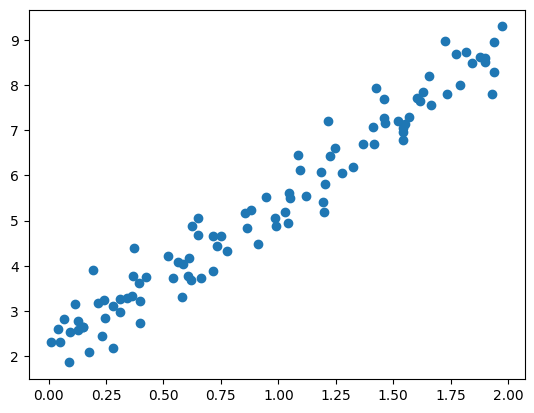

In [9]:
plt.scatter(X, y)

## Closed-form solution equivalent

In [63]:
model = SimpleLinearRegression()

model.train(X, y)

b0, b1 = model.params()

print("Parameters:")
print(f"\tb0 = {b0}")
print(f"\tb1 = {b1}")

print("Best fit line:")
print(f"\ty = {b0:.2f} + {b1:.2f}x")

Parameters:
	b0 = 2.1075480787733736
	b1 = 3.385056693219239
Best fit line:
	y = 2.11 + 3.39x


## Implementation of gradient descent

$$L = \sum(y-mx-b)^2$$
$$
\frac{\partial L}{\partial m} = -2\sum{x(y-mx-b)}
$$
$$
\frac{\partial L}{\partial b} = -2\sum{(y-mx-b)}
$$


In [53]:
def partial_m(X, Y, m, b):
    result = 0
    for x, y in zip(X, Y):
        result += x * (y - m*x - b)
    result *= -2
    return result

def partial_b(X, Y, m, b):
    result = 0
    for x, y in zip(X, Y):
        result += y - m*x - b
    result *= -2
    return result

In [71]:
fixed_m = b1

init_b = 0
init_m = 0
lr = 0.001 # Added learning rate variable!

slope_b = partial_b(X, y, init_m, init_b)
step_b = slope_b * lr
next_b = init_b - step_b

slope_m = partial_m(X, y, init_m, init_b)
step_m = slope_m * lr
next_m = init_m - step_m

while abs(step_b) > 1e-10 or abs(step_m) > 1e-10:
    slope_b = partial_b(X, y, next_m, next_b)
    step_b = slope_b * lr
    next_b = next_b - step_b

    slope_m = partial_m(X, y, next_m, next_b)
    step_m = slope_m * lr
    next_m = next_m - step_m
    
print(next_b)
print(next_m)

2.1075480812482676
3.3850566910804902


In [69]:
n = len(X)
c_s = np.sum(y - fixed_m * X)
c_q = np.sum(np.square(y - fixed_m * X))

n, c_s, c_q

(100, np.float64(210.75480787733764), np.float64(464.34050453331156))

> My question is, how do we properly select for the best learning rate?